<a href="https://colab.research.google.com/github/winengewe/energy-consumption-mlp/blob/main/energy_consumption_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Predict the daily total electrical consumption of their customers in each borough.

The datasets provided have been adapted and transformed from:

London daily weather 1979 to 2021:
*  https://www.kaggle.com/datasets/emmanuelfwerr/london-weather-data

London hourly energy dataset 2011 to 2014:
*  https://www.kaggle.com/datasets/emmanuelfwerr/london-homes-energy-data


# Project Assessment

**1) What stages will you follow in this data science project?**

There are 7 stages in this data science project:
1) Business Understanding & Problem Definition - I will define what are we solving and why. I will identify the problem type is either classification or regression.
2) Data Collection - I will read csv files in Google Colab
3) Data Cleaning & Preparation - I will handle missing data, formatting data types, identify the outliner
4) Exploratory Data Analysis (EDA) - I will use visualization (heatmap, scatter plot, histograms) via seaborn and matplotlib to see the patterns of the data.
5) Feature Engineering & Selection - I will create data points that make model smarter by 3 methods.
*   First is transformation, by converting the categorical text data in numbers (using the 'One-hot encode' methods), and scalling the numbers to the same range (using standardization).
*    Second is feature creation, by creating new variables eg. 'week' & 'day' & 'year' columns from the 'date' column.
*   Third is selection, by removing irrelevant or reduntant variables to improve model performance and speed, eg. remove 'year' column as an inputs for deep learning model as it is constant througout the year.
6) Modeling & Evaluation - I will choose the right tools for the job (eg. I pick 'gelu' activation function for regression problem; I pick 'softmax' activation function for classification problem. After select the model, I will train the model using split datasets (70:30 for test/train dataset). For model evaluation, I will pick 'MeanAbsoluteError' & 'MeanAbsolutePercentageError' metrics for regression problem; I will pick 'SparseCategoricalAccuracy' metrics for classification problem.
7) Deployment & Communication - I will use the model to predict the outputs and translating complex mathematical results into clear business recommendations.

**2) What roles are there in your data science project team?**

Answered by the project manager:

*   Data analyst who cleaned, analysed, visualised and presented the data
*   Data scientist (yourself) who created deep learning models to perform predictive analysis
*   Project manager

**3) What project management methods and software did you use?**

Answered by the project manager:
*   Microsoft Project
*   Waterfall

**3) What were the project and data requirements?**

Answered by the project manager:

We have hired a data science project team for a fictional London energy company. They would like the data scientist on this team to join two datasets together to allow themselves to predict the daily total electrical consumption of their customers in each borough.


**5) How did you allocate of tasks and resources?**

Answered by the project manager:

*   Gantt chart of data science stages split into subtasks and assigned to above roles
*   Some of the subtasks have been provided as part of this assessment colab
*   Resources used such as equipment




**6) What collaboration tools did you use?**

Answered by the project manager:

*   Google Colab



**7) What version control systems did you use?**

Answered by the project manager:
*   Version control built into Google Colab


**8) Any ethical and legal considerations, including data bias?**

No

# Practical Assessment

**9) Read the [London weather dataset](https://drive.google.com/file/d/1eT1YaXgNIjxFPjPfzpQHWLaWwK54s_uC/view?usp=sharing) into a Pandas Dataframe**

In [ ]:
# import libraries
from google.colab import drive
drive.mount('/content/gdrive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
# read dataset
london_weather=pd.read_csv("gdrive/My Drive/Pro AI & Data Science course/pda_8_london_weather.csv")

**10) Explore the London weather dataset statistically with Pandas**

In [ ]:
# check missing values
print("\nMissing values:\n", london_weather.isnull().sum()) # Show the total of missing values for each column


Missing values:
 date                   0
cloud_cover         4018
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64


seems like many missing data. most on 'cloud_cover' and 'snow_depth'.

In [ ]:
# check dataset statistically
print('Data Info')
print(london_weather.info())
print('\nData Head (First5rows)')
print(london_weather.head())
print('\nData Tail (Last5rows)')
print(london_weather.tail())
print('\nData Describe')
print(london_weather.describe())

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              15341 non-null  int64  
 1   cloud_cover       11323 non-null  float64
 2   sunshine          15341 non-null  float64
 3   global_radiation  15322 non-null  float64
 4   max_temp          15335 non-null  float64
 5   mean_temp         15305 non-null  float64
 6   min_temp          15339 non-null  float64
 7   precipitation     15335 non-null  float64
 8   pressure          15337 non-null  float64
 9   snow_depth        13900 non-null  float64
dtypes: float64(9), int64(1)
memory usage: 1.2 MB
None

Data Head (First5rows)
       date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
0  19790101          NaN       7.0              52.0       2.3       -4.1   
1  19790102          NaN       1.7              27.0       1.6       -2.6   
2  1979

data type is int and float. we might need to use Lambda expressions to make new day/month/years columns from the original date columns or change the format

In [ ]:
# check strong data correlation
london_weather.corr(numeric_only=True)

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
date,1.000000,-0.128769,0.009067,0.008132,0.086843,0.094389,0.095322,0.008122,-0.013423,-0.043738
cloud_cover,-0.128769,1.000000,-0.735163,-0.487883,-0.226016,-0.123220,0.040118,0.239118,-0.241951,0.020622
sunshine,0.009067,-0.735163,1.000000,0.852632,0.472182,0.396535,0.219082,-0.231636,0.226943,-0.034222
global_radiation,0.008132,-0.487883,0.852632,1.000000,0.690946,0.635432,0.478119,-0.162668,0.150078,-0.061781
max_temp,0.086843,-0.226016,0.472182,0.690946,1.000000,0.912200,0.810514,-0.071799,0.100455,-0.130594
mean_temp,0.094389,-0.123220,0.396535,0.635432,0.912200,1.000000,0.955593,-0.010462,0.004764,-0.154945
min_temp,0.095322,0.040118,0.219082,0.478119,0.810514,0.955593,1.000000,0.037233,-0.074274,-0.157882
precipitation,0.008122,0.239118,-0.231636,-0.162668,-0.071799,-0.010462,0.037233,1.000000,-0.349456,-0.001352
pressure,-0.013423,-0.241951,0.226943,0.150078,0.100455,0.004764,-0.074274,-0.349456,1.000000,-0.021229
snow_depth,-0.043738,0.020622,-0.034222,-0.061781,-0.130594,-0.154945,-0.157882,-0.001352,-0.021229,1.000000


In [ ]:
# check strong data correlation
correlation_matrix = london_weather.corr(numeric_only=True)
strong_correlations = correlation_matrix[((correlation_matrix > 0.5) | (correlation_matrix < -0.5)) & (correlation_matrix != 1.0)]
display(strong_correlations)

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
date,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cloud_cover,NaN,NaN,-0.735163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sunshine,NaN,-0.735163,NaN,0.852632,NaN,NaN,NaN,NaN,NaN,NaN
global_radiation,NaN,NaN,0.852632,NaN,0.690946,0.635432,NaN,NaN,NaN,NaN
max_temp,NaN,NaN,NaN,0.690946,NaN,0.912200,0.810514,NaN,NaN,NaN
mean_temp,NaN,NaN,NaN,0.635432,0.912200,NaN,0.955593,NaN,NaN,NaN
min_temp,NaN,NaN,NaN,NaN,0.810514,0.955593,NaN,NaN,NaN,NaN
precipitation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pressure,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
snow_depth,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**11) Explore the London weather dataset visually with Matplotlib and/or Seaborn. This must include a visualisation of timeseries data**

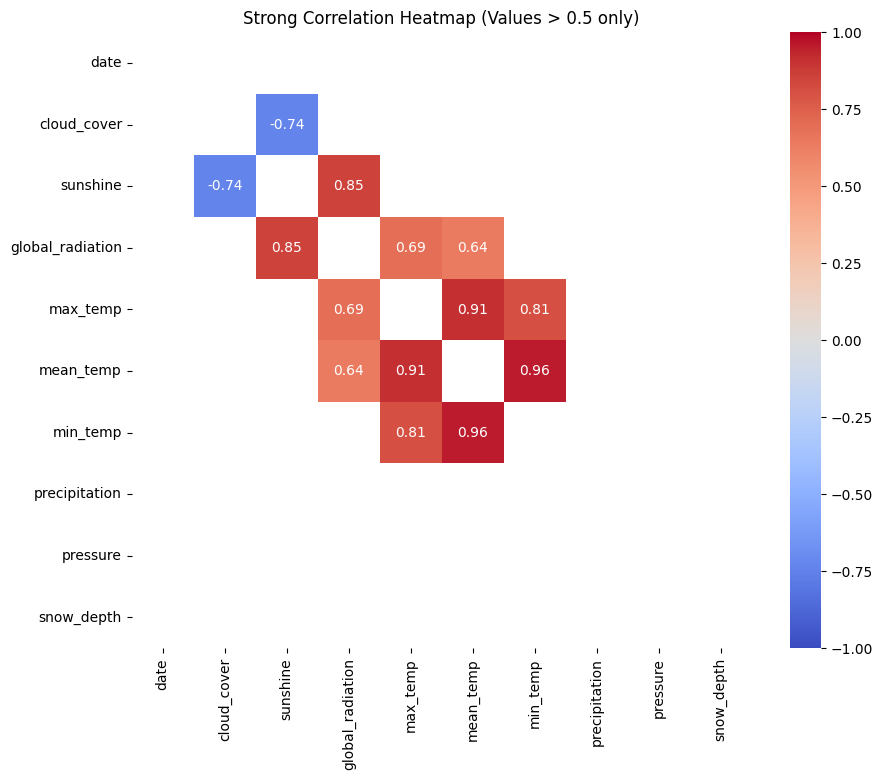

In [ ]:
# plot Strong Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = london_weather.corr(numeric_only=True)
mask = (abs(corr) <= 0.5) | (np.eye(len(corr), dtype=bool)) #
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Strong Correlation Heatmap (Values > 0.5 only)")
plt.show()

Strong Positive Correlations:

global_radiation and sunshine (0.85): More sunshine strongly relates to more radiation.

max_temp, mean_temp, and min_temp are all highly correlated with each other (> 0.8), as expected.

global_radiation and max_temp (0.69): Radiation is a significant driver of maximum temperature.

global_radiation and mean_temp (0.64): Radiation is a significant driver of mean temperature.

Strong Negative Correlations:

cloud_cover and sunshine (-0.74): More clouds mean less sunshine.

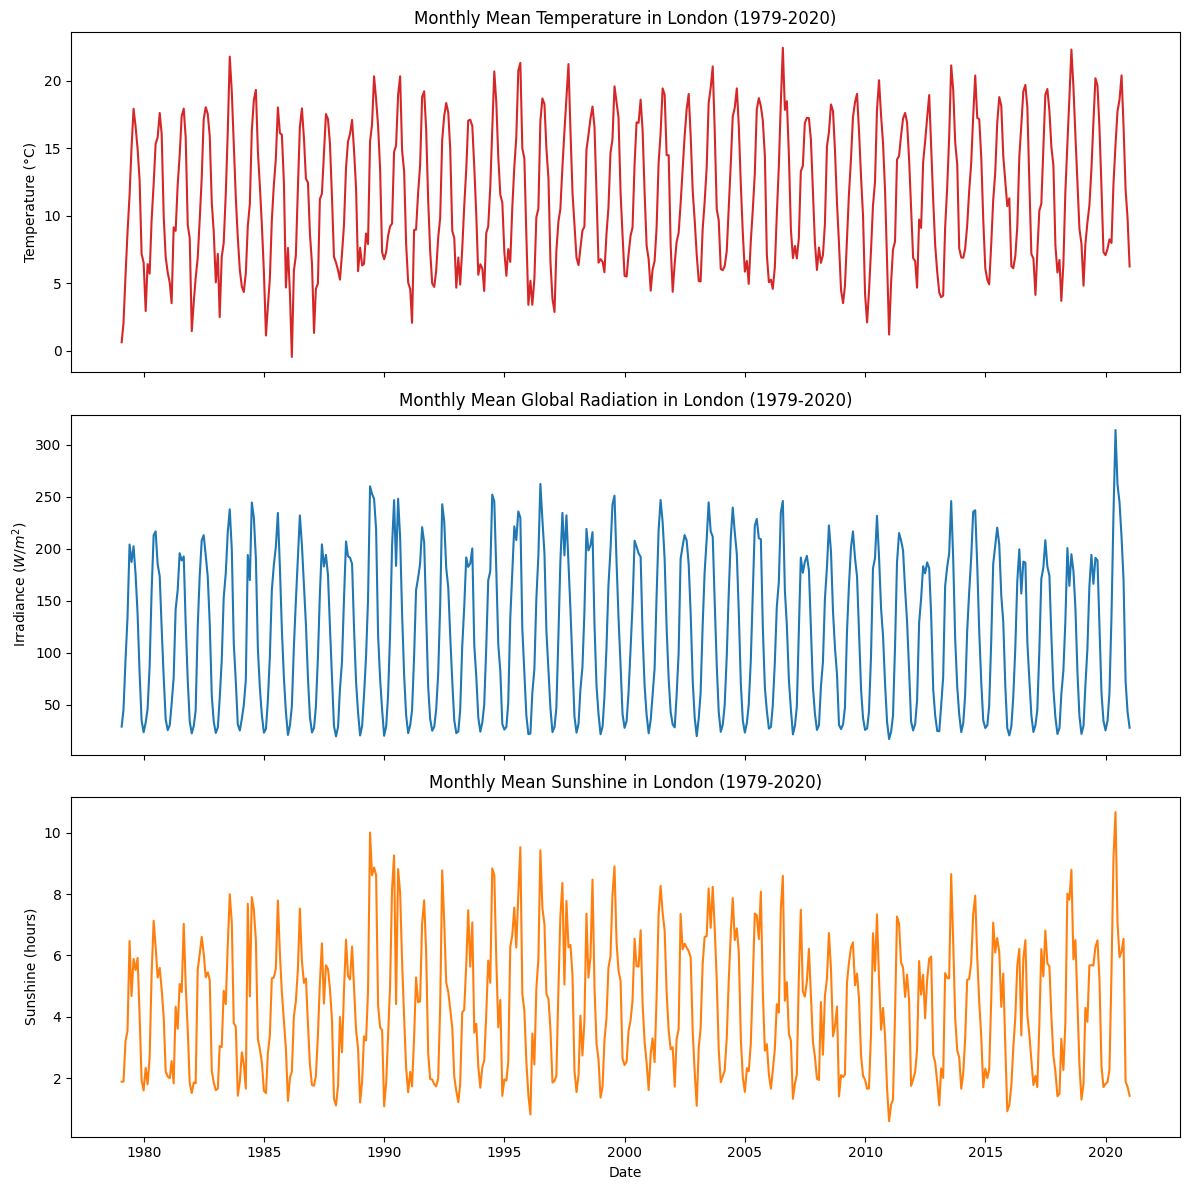

In [ ]:
#plot time-series data

import matplotlib.pyplot as plt

London_weather = london_weather.copy()
# Convert date to datetime

London_weather['date'] = pd.to_datetime(London_weather['date'], format='%Y%m%d')

# Set date as index
London_weather.set_index('date', inplace=True)

# Resample to monthly mean to reduce noise and make the plot clearer
df_monthly = London_weather.resample('ME').mean()

# Create subplots
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 12), sharex=True)

# Plot Mean Temperature
axes[0].plot(df_monthly.index, df_monthly['mean_temp'], color='tab:red')
axes[0].set_title('Monthly Mean Temperature in London (1979-2020)')
axes[0].set_ylabel('Temperature (°C)')

# Plot Precipitation
axes[1].plot(df_monthly.index, df_monthly['global_radiation'], color='tab:blue')
axes[1].set_title('Monthly Mean Global Radiation in London (1979-2020)')
axes[1].set_ylabel('Irradiance ($W/m^2$)')

# Plot Sunshine
axes[2].plot(df_monthly.index, df_monthly['sunshine'], color='tab:orange')
axes[2].set_title('Monthly Mean Sunshine in London (1979-2020)')
axes[2].set_ylabel('Sunshine (hours)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('london_weather_timeseries.png')

Mean Temperature: Shows a clear seasonal cycle with temperatures peaking in summer and dipping in winter.

Global radiation: Follows a strong seasonal pattern similar to temperature, with more irradiance in the summer months.

Sunshine: Follows a strong seasonal pattern similar to temperature, with more sunshine hours in the summer months.

The cloud_cover column has missing data before the 1990s. You decide to fill this rather than drop the empty rows. This process will involve:
*   Dropping all missing data and store in a new dataframe
*   Creating standardised Numpy different sets from this with the cloud_cover as the label
*   Training a deep learning classification model to fill in the missing decade of cloud_cover
*   Testing this deep learning model
*   Filling in the missing cloud_cover on the original dataframe using this classification model

**12) Drop all the missing rows in your original dataframe and store in a new dataframe**

In [ ]:
# Drop all the missing rows in your original dataframe and store in a new dataframe
# london_weather_without_nan = london_weather.dropna() # Drop rows with missing values
london_weather.dropna(subset=london_weather.columns.drop('cloud_cover'), inplace=True)
london_weather_with_nan = london_weather[london_weather['cloud_cover'].isna()]
london_weather_without_nan = london_weather[london_weather['cloud_cover'].notna()]
print("\nlondon_weather_with_nan:\n", london_weather_with_nan.isnull().sum())
print("\nlondon_weather_without_nan:\n", london_weather_without_nan.isnull().sum())


london_weather_with_nan:
 date                   0
cloud_cover         4017
sunshine               0
global_radiation       0
max_temp               0
mean_temp              0
min_temp               0
precipitation          0
pressure               0
snow_depth             0
dtype: int64

london_weather_without_nan:
 date                0
cloud_cover         0
sunshine            0
global_radiation    0
max_temp            0
mean_temp           0
min_temp            0
precipitation       0
pressure            0
snow_depth          0
dtype: int64


**13) Create Numpy arrays in preparation for training and testing your deep learning model. These will need to be standardised and split into training and testing sets.**

In [ ]:
# Prepare ML datasets
x = london_weather_without_nan.drop(columns=['date','cloud_cover']).to_numpy(dtype='float32') # create multi-dimensional array x
# x = london_weather_without_nan[['sunshine']].to_numpy(dtype='float32') # create a numpy array y
y = london_weather_without_nan[['cloud_cover']].to_numpy(dtype='float32') # create a numpy array y
print('x.shape:',x.shape)
print('y.shape:',y.shape)

x.shape: (9844, 8)
y.shape: (9844, 1)


In [ ]:
# Split datasets in 70%/30% ratio
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)
print('x_train.shape:',x_train.shape)
print('y_train.shape:',y_train.shape)
print('x_test.shape:',x_test.shape)
print('y_test.shape:',y_test.shape)

x_train.shape: (7875, 8)
y_train.shape: (7875, 1)
x_test.shape: (1969, 8)
y_test.shape: (1969, 1)


In [ ]:
# Standardise features for model stability
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

**14) Create and train a deep learning classification model using Tensorflow/Keras. This must:**
*   Use inverted bottlenecks
*   Use residual connections
*   Use gelu activations
*   Use a softmax for output layer
*   Use the sparse categorical crossentropy loss
*   Use the adam optimizer

In [ ]:
# Create keras deep learning model

# Import keras from the tensorflow library
from tensorflow import keras
import numpy as np

# Define parameters
hiddenlayers = 2 # pick 2 / 3 / 4
problem = 'classification'
# pick 'classification' for categorical data (yes/no) /
# pick 'regression' for quantitative data, consists of discrete & continuous data (predict a value)

outputs_no = 10
# 2 outputs either 'fraud' or 'no fraud' /
# 1 output for regression predicted value /
# 10 for MNIST-1D

# Create an input layer which expects same as x_train columns
inputs = keras.layers.Input(shape=(np.shape(x_train)[1],))

# Projection layer
z = keras.layers.Dense(64*hiddenlayers)(inputs) # for 'keras.layers.Add' same size with s

# Dropout on linear projection
z = keras.layers.Dropout(0.1)(z)

# Create an artificiail neural network (ANN)
for i in range(hiddenlayers): # determine how deep or shallow the ANN

  # Skip / Shortcut connection
  s = z

  # Pre Layer Norm
  z = keras.layers.LayerNormalization()(z)

  # Inverted bottleneck
  z = keras.layers.Dense(4*64*hiddenlayers)(z) # Expand neurons in this dimension
  z = keras.activations.gelu(z)
  z = keras.layers.Dense(64*hiddenlayers)(z) # Reduce these neurons using a linear layer

  # Dropout on linear projection
  z = keras.layers.Dropout(0.1)(z)

  # Skip / Add the shortcut connection with the output of the block
  z = keras.layers.Add()([s,z])

# Pre Layer Norm
z = keras.layers.LayerNormalization()(z)

# Output layer
z = keras.layers.Dense(outputs_no)(z)

if problem == 'classification':
  outputs = keras.activations.softmax(z)
else: # problem == 'regression'
  outputs = keras.activations.gelu(z)
  # outputs = keras.activations.linear(z)

# Create a keras model using the above inputs and outputs
model = keras.Model(inputs=[inputs], outputs=[outputs])

# Check model
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 8)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 128)       │      1,152 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ dropout_6[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 512)       │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_5 (Gelu)       │ (None, 512)       │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 128)       │     65,664 │ gelu_5[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 128)       │          0 │ dropout_6[0][0],  │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 512)       │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_6 (Gelu)       │ (None, 512)       │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 128)       │     65,664 │ gelu_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 128)       │          0 │ add_4[0][0],      │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 10)        │      1,290 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax_1 (Softmax) │ (None, 10)        │          0 │ dense_17[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 266,634 (1.02 MB)

 Trainable params: 266,634 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Run the model

import numpy as np
ilr = 0.01 # initial_learning_rate
epochs = 15 # complete passes through the entire training dataset by the learning algorithm
steps_per_epoch = np.ceil(np.shape(x_train)[0] / 32)
print(steps_per_epoch)

if problem == 'classification':
  model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=keras.optimizers.schedules.CosineDecay(initial_learning_rate=ilr, decay_steps=epochs*steps_per_epoch)),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
  )
else: # problem == 'regression'
  model.compile(
  loss=keras.losses.MeanSquaredError(),
  optimizer=keras.optimizers.Adam(learning_rate=keras.optimizers.schedules.CosineDecay(initial_learning_rate=ilr, decay_steps=epochs*steps_per_epoch)),
  metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()]
  )

model.fit(x_train, y_train, epochs=epochs)

247.0
Epoch 1/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - loss: 1.9603 - sparse_categorical_accuracy: 0.2819
Epoch 2/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5757 - sparse_categorical_accuracy: 0.3292
Epoch 3/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5327 - sparse_categorical_accuracy: 0.3399
Epoch 4/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5323 - sparse_categorical_accuracy: 0.3385
Epoch 5/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5177 - sparse_categorical_accuracy: 0.3623
Epoch 6/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5297 - sparse_categorical_accuracy: 0.3391
Epoch 7/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.5041 - sparse_categorical_accuracy: 0.3446
Epoch 8/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4868 - sparse_categorical_accuracy: 0.3613
Epoch 9/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.4740 - sparse_categorical_accuracy: 0.3664
Epoch 10/15
247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms

In [ ]:
# Measure the performance on both the training and testing sets
print('Train model score:',model.evaluate(x_train, y_train))
print('Test model score:',model.evaluate(x_test, y_test))

247/247 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.4229 - sparse_categorical_accuracy: 0.3953
Train model score: [1.428822636604309, 0.39885714650154114]
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4271 - sparse_categorical_accuracy: 0.3978
Test model score: [1.4334256649017334, 0.37938040494918823]


**15) Evaluate the performance of this deep learning model of both the training and test sets. This must include the use of:**
*   Sklearn confusion matrix
*   Sklearn classification report

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions for training and test sets
y_pred_train_probs = model.predict(x_train)
y_pred_test_probs = model.predict(x_test)

"""
Classification metrics can't handle a mix of multiclass and multilabel-indicator targets
means that the format of your true labels (y_train) and
predicted labels (y_pred_train.round()) are incompatible
for the confusion_matrix and classification_report functions.
Your model outputs probabilities for each class,
and simply rounding these probabilities doesn't give you the single,
discrete class labels that sklearn expects.

To fix this, use np.argmax on the model's predictions
to get the most likely class for each sample,
eg. Correctly converts your model's probability outputs (e.g., [0.1, 0.8, 0.1])
into a single discrete class label (e.g., 1).
and flatten true labels (y_train and y_test) to a 1D integer array for confusion_matrix
"""

# Convert probabilities to class labels
y_pred_train_classes = np.argmax(y_pred_train_probs, axis=1)
y_pred_test_classes = np.argmax(y_pred_test_probs, axis=1)

# Flatten y_train and y_test for sklearn metrics
y_train_flat = y_train.flatten().astype(int)
y_test_flat = y_test.flatten().astype(int)

# Evaluate on training set
print("\n--- Training Set Evaluation ---")
cm_train = confusion_matrix(y_train_flat, y_pred_train_classes)
print("\nConfusion Matrix (Train):\n", cm_train)
report_train = classification_report(y_train_flat, y_pred_train_classes, zero_division=0)
print("\nClassification Report (Train):\n", report_train)

# Evaluate on test set
print("\n--- Test Set Evaluation ---")
cm_test = confusion_matrix(y_test_flat, y_pred_test_classes)
print("\nConfusion Matrix (Test):\n", cm_test)
report_test = classification_report(y_test_flat, y_pred_test_classes, zero_division=0)
print("\nClassification Report (Test):\n", report_test)

247/247 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

--- Training Set Evaluation ---

Confusion Matrix (Train):
 [[ 67  53  53   9  11   3   3   2   0   0]
 [ 22  79 100  43  44  18   3   0   2   0]
 [ 29  47 135  53 118  53  26   6   0   0]
 [ 12  29 110  70 183 112  56  10   0   0]
 [  2  22  63  58 260 284 178  41   5   0]
 [  5  10  47  37 179 365 418 104  18   0]
 [  1   2  16  10  78 232 695 409  98   0]
 [  0   0   2   1  16  73 411 783 373   0]
 [  0   0   0   0   0   2  23 304 687   0]
 [  0   0   0   0   0   0   0   0   2   0]]

Classification Report (Train):
               precision    recall  f1-score   support

           0       0.49      0.33      0.40       201
           1       0.33      0.25      0.29       311
           2       0.26      0.29      0.27       467
           3       0.25      0.12      0.16       582
           4       0.29      0.28      0.29       913
           5       0.32      0.31      0.31      1183
           6    

Confusion matrix(test):

The diagonal in the matrix is the number of the corrected predicted samples for the specific class. eg. [0,0] for test set is 19 samples are correctly identified as class '0'; [0,1] is 16 samples are incorrectly classified as '1'.

Classification report(test):
*   precision for class '1': 17/sum of the column = 0.24 (correct predicted positive observation divided by positive observations)
*   recall for class '1': 13/sum of the row class '1' = 0.18 (correct predicted positive observation divided by all observations in the class)
*   f1-score: avg of precision and recall
*   support: samples in the test set
*   Accuracy: The overall accuracy on the training set is approximately 38%, meaning 38% of the test samples were classified correctly.









**15) Evaluate using this model for filling in missing cloud_cover data**



In [ ]:
# Off-By-One Accuracy
# Calculate how often your prediction is exactly right OR within 1 unit of the truth.

import numpy as np

# Calculate the absolute difference between predictions and actual values
diff_train = np.abs(y_train_flat - y_pred_train_classes)
diff_test = np.abs(y_test_flat - y_pred_test_classes)

# Exact Accuracy (Same as standard accuracy)
exact_acc_train = np.mean(diff_train == 0)
exact_acc_test = np.mean(diff_test == 0)

# Off-by-One Accuracy (Tolerance of +/- 1 class)
# This considers a prediction correct if it's the exact class
# OR immediately adjacent neighbors.
relaxed_acc_train = np.mean(diff_train <= 1)
relaxed_acc_test = np.mean(diff_test <= 1)

print("\n--- Custom Cloud Cover Metrics (Train) ---")
print(f"Exact Match Accuracy:      {exact_acc_train:.2%}")
print(f"Relaxed (Off-by-1) Accuracy: {relaxed_acc_train:.2%}")

print("\n--- Custom Cloud Cover Metrics (Test) ---")
print(f"Exact Match Accuracy:      {exact_acc_test:.2%}")
print(f"Relaxed (Off-by-1) Accuracy: {relaxed_acc_test:.2%}")


--- Custom Cloud Cover Metrics (Train) ---
Exact Match Accuracy:      39.89%
Relaxed (Off-by-1) Accuracy: 81.00%

--- Custom Cloud Cover Metrics (Test) ---
Exact Match Accuracy:      37.94%
Relaxed (Off-by-1) Accuracy: 81.11%


If Relaxed Accuracy is significantly higher than Exact Accuracy: The model is actually doing well! It captures the general trend of the weather (e.g., it knows it's "cloudy") but struggles with the precise degree (e.g., distinguishing 6/8 from 7/8 oktas).

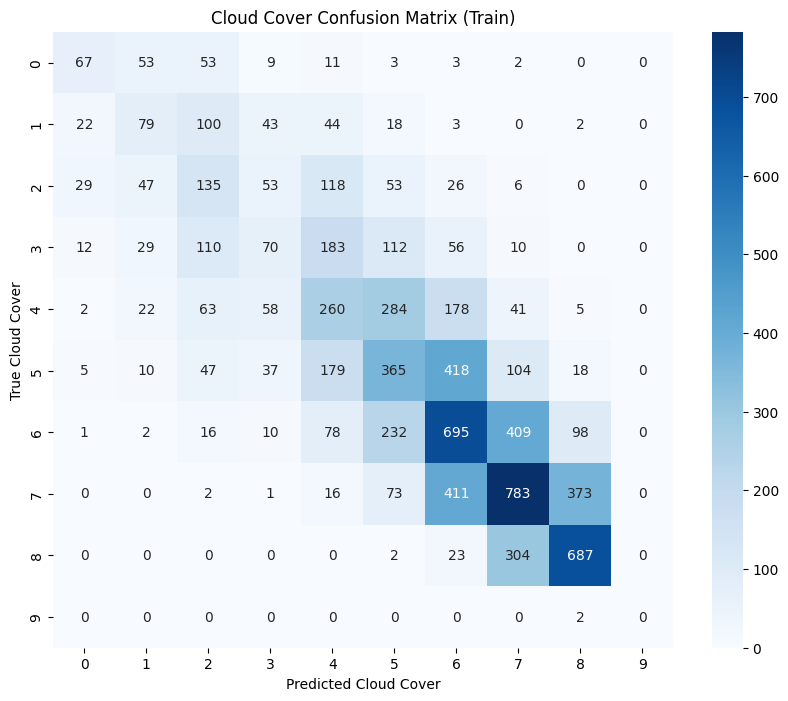

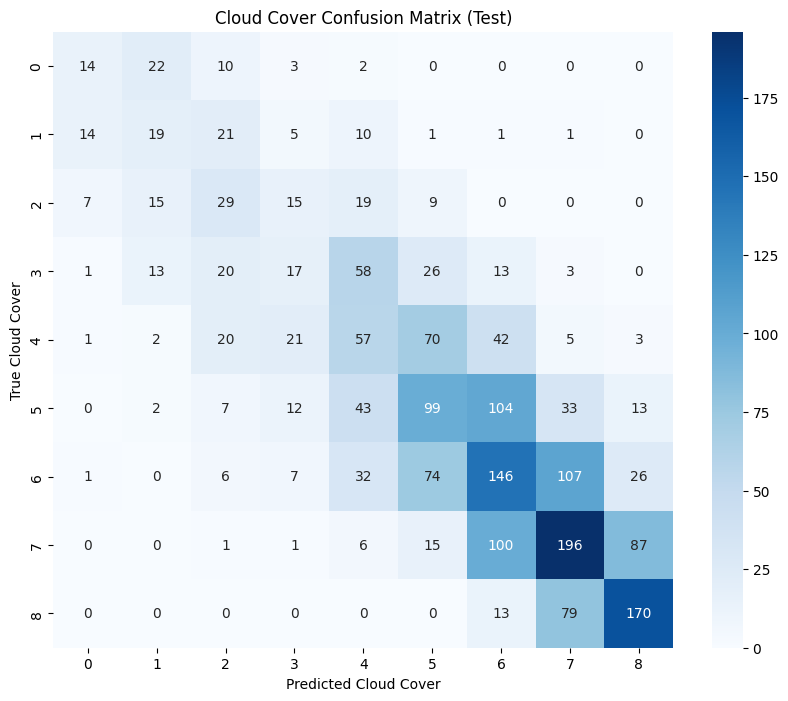

In [ ]:
# Visualizing the Errors
# Raw text matrices are hard to read. Use a Heatmap to spot the "Spread" of your errors.

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Cloud Cover')
plt.ylabel('True Cloud Cover')
plt.title('Cloud Cover Confusion Matrix (Train)')
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Cloud Cover')
plt.ylabel('True Cloud Cover')
plt.title('Cloud Cover Confusion Matrix (Test)')
plt.show()

If the Heatmap shows scattered spots far from the diagonal: The model is confused. For example, predicting "Clear" (0) when it is actually "Overcast" (8) suggests the input features (like humidity or pressure) aren't strong enough to distinguish these states.

This heatmap shows scattered sports near to the diagonal: The model is doing well.

**16) Replace the missing cloud_cover data in the original dataset using this classification model**

In [ ]:
# Prepare for inference and replacing missing values
x = london_weather_with_nan.drop(columns=['date','cloud_cover']).to_numpy(dtype='float32') # create multi-dimensional array x
print(x.shape)

(4017, 8)


In [ ]:
# Standardise the input with above values
x = scaler.transform(x)

In [ ]:
# Infer
y_pred = model.predict(x)
print(y_pred)

126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[9.4245248e-02 1.1394715e-01 1.7468090e-01 ... 2.0030405e-02
  6.4046993e-03 6.2718021e-04]
 [2.9052338e-02 2.3838874e-02 4.7133692e-02 ... 1.5343319e-01
  1.7219350e-01 2.0744812e-03]
 [9.6034585e-03 6.8914299e-03 1.5561403e-02 ... 2.0707551e-01
  3.6975375e-01 2.6266654e-03]
 ...
 [4.3432802e-04 3.0768846e-04 7.8001828e-04 ... 2.9221100e-01
  6.2493628e-01 3.6137144e-04]
 [4.8411649e-04 3.3296534e-04 8.3092268e-04 ... 2.8410318e-01
  6.3087279e-01 4.2032797e-04]
 [5.8408570e-04 3.8092001e-04 9.3547162e-04 ... 2.7369297e-01
  6.3010764e-01 6.1384845e-04]]


In [ ]:
# Column 2 is where missing values are
london_weather.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,19790101,NaN,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,19790102,NaN,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,19790103,NaN,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,19790104,NaN,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,19790105,NaN,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [ ]:
# Replace the column 2 values (first 730) with the model predictions
london_weather_filled = london_weather.copy()
london_weather_filled.loc[london_weather_filled['cloud_cover'].isna(), 'cloud_cover'] = np.argmax(y_pred, axis=-1)
print('london_weather_filled.head(5)',london_weather_filled.head(5))
print('london_weather_filled.tail(5)',london_weather_filled.tail(5))

london_weather_filled.head(5)        date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
0  19790101          2.0       7.0              52.0       2.3       -4.1   
1  19790102          6.0       1.7              27.0       1.6       -2.6   
2  19790103          8.0       0.0              13.0       1.3       -2.8   
3  19790104          8.0       0.0              13.0      -0.3       -2.6   
4  19790105          5.0       2.0              29.0       5.6       -0.8   

   min_temp  precipitation  pressure  snow_depth  
0      -7.5            0.4  101900.0         9.0  
1      -7.5            0.0  102530.0         8.0  
2      -7.2            0.0  102050.0         4.0  
3      -6.5            0.0  100840.0         2.0  
4      -1.4            0.0  102250.0         1.0  
london_weather_filled.tail(5)            date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
14970  20191227          8.0       0.0              12.0       9.6        7.5   
14971  20

**17) Read the [London energy dataset](https://drive.google.com/file/d/1elYGf3VwdDuMhkGGzFA9STGax6sq3iLT/view?usp=sharing) into a Pandas Dataframe**

In [ ]:
# read dataset
london_energy=pd.read_csv("gdrive/My Drive/Pro AI & Data Science course/pda_8_london_energy.csv")

**18) Explore the London energy dataset statistically**

In [ ]:
# check missing values
print("\nMissing values:\n", london_energy.isnull().sum()) # Show the total of missing values for each column


Missing values:
 Date         0
MWH          0
Borough      0
Latitude     0
Longitude    0
dtype: int64


In [ ]:
# check dataset statistically
print('Data Info')
print(london_energy.info())
print('\nData Head (First5rows)')
print(london_energy.head())
print('\nData Tail (Last5rows)')
print(london_energy.tail())
print('\nData Describe')
print(london_energy.describe())

Data Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27357 entries, 0 to 27356
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       27357 non-null  object 
 1   MWH        27357 non-null  float64
 2   Borough    27357 non-null  object 
 3   Latitude   27357 non-null  float64
 4   Longitude  27357 non-null  float64
dtypes: float64(3), object(2)
memory usage: 1.0+ MB
None

Data Head (First5rows)
         Date         MWH         Borough  Latitude  Longitude
0  2011-11-23  399.183637  City of London   51.5155    -0.0922
1  2011-11-23  591.740132          Sutton   51.3618    -0.1945
2  2011-11-23  474.632741           Brent   51.5588    -0.2817
3  2011-11-23  682.400587   Tower Hamlets   51.5099    -0.0059
4  2011-11-23  250.397296         Croydon   51.3714    -0.0977

Data Tail (Last5rows)
             Date         MWH      Borough  Latitude  Longitude
27352  2014-02-28  421.651193        Brent   51.5588    

In [ ]:
# check strong data correlation
london_energy.corr(numeric_only=True)

,MWH,Latitude,Longitude
MWH,1.000000,0.105951,-0.174887
Latitude,0.105951,1.000000,0.121507
Longitude,-0.174887,0.121507,1.000000


In [ ]:
# check strong data correlation
correlation_matrix = london_energy.corr(numeric_only=True)
strong_correlations = correlation_matrix[((correlation_matrix > 0.5) | (correlation_matrix < -0.5)) & (correlation_matrix != 1.0)]
display(strong_correlations)

,MWH,Latitude,Longitude
MWH,NaN,NaN,NaN
Latitude,NaN,NaN,NaN
Longitude,NaN,NaN,NaN


**19) Explore the London energy dataset visually. This must include visualising geospatial data.**

The data analyst on your team has created the geospatial visualisation below. To work with this visualisation you will need to create a new data frame called df_summed, which is grouped by Borough then has aggregations for total MWH, then Latitude and Longitude.

In [ ]:
df_summed = london_energy.groupby('Borough').agg(MWH=('MWH', 'sum'),Latitude=('Latitude', 'mean'),Longitude=('Longitude', 'mean')).reset_index()
df_summed.head()

,Borough,MWH,Latitude,Longitude
0,Barking and Dagenham,295595.279025,51.5607,0.1557
1,Barnet,486737.637889,51.6252,-0.1517
2,Bexley,247329.218682,51.4549,0.1505
3,Brent,508697.149158,51.5588,-0.2817
4,Bromley,415251.414736,51.4039,0.0198


In [ ]:
import folium
from folium.plugins import MarkerCluster
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Create a map centered around London
m = folium.Map(location=[51.5074, -0.1278], zoom_start=10, tiles='OpenStreetMap')

# Create a MarkerCluster to add multiple markers
marker_cluster = MarkerCluster().add_to(m)

norm = colors.Normalize(vmin=df_summed['MWH'].min(), vmax=df_summed['MWH'].max())

# Add markers with colour proportional to MWH values
for index, row in df_summed.iterrows():
    color = plt.cm.jet(norm(row['MWH']))
    color_hex = colors.rgb2hex(color)
    folium.CircleMarker(location=[row['Latitude'], row['Longitude']],
                        color=color_hex,
                        fill_color=color_hex,
                        fill_opacity=0.5).add_to(marker_cluster)

# Display the map
m

**20) Change the weather datasets date to the format YYYY-MM-DD. This is in prepartion for joining both the weather and energy datasets by date.**

In [ ]:
# Lambda expressions to make new date formate from the original date columns
london_weather_filled_date = london_weather_filled.copy()
london_weather_filled_date["date"] = london_weather_filled_date["date"].astype("string")
london_weather_filled_date['date'] = london_weather_filled_date['date'].apply(lambda x: x[:4] + "-" + x[4:6] + "-" + x[6:])
london_weather_filled_date.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,1979-01-01,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,1979-01-02,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,1979-01-03,8.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,1979-01-04,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,1979-01-05,5.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


**21) Perform an inner join using Pandas merge on the weather and energy datasets together by the date/Date columns**

In [ ]:
# Make the the joint columns have the same title
london_energy_date = london_energy.rename(columns={"Date": "date"})
print(london_energy_date.head(10))
print(london_weather_filled_date.head(10))

         date         MWH               Borough  Latitude  Longitude
0  2011-11-23  399.183637        City of London   51.5155    -0.0922
1  2011-11-23  591.740132                Sutton   51.3618    -0.1945
2  2011-11-23  474.632741                 Brent   51.5588    -0.2817
3  2011-11-23  682.400587         Tower Hamlets   51.5099    -0.0059
4  2011-11-23  250.397296               Croydon   51.3714    -0.0977
5  2011-11-23  188.488234              Haringey   51.6000    -0.1119
6  2011-11-23  281.446519  Kingston upon Thames   51.4085    -0.3064
7  2011-11-23  465.074306                Barnet   51.6252    -0.1517
8  2011-11-23  526.216308             Islington   51.5416    -0.1022
9  2011-11-23  664.446583            Hillingdon   51.5441    -0.4760
         date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
0  1979-01-01          2.0       7.0              52.0       2.3       -4.1   
1  1979-01-02          6.0       1.7              27.0       1.6       -2.6   
2  1

In [ ]:
# Merging on multiple columns
df_combined = pd.merge(london_weather_filled_date, london_energy_date, on=['date'], how='inner')
print(df_combined.head(10))
print(df_combined.tail(10))

         date  cloud_cover  sunshine  global_radiation  max_temp  mean_temp  \
0  2011-11-23          7.0       2.0              35.0      13.5        6.8   
1  2011-11-23          7.0       2.0              35.0      13.5        6.8   
2  2011-11-23          7.0       2.0              35.0      13.5        6.8   
3  2011-11-23          7.0       2.0              35.0      13.5        6.8   
4  2011-11-23          7.0       2.0              35.0      13.5        6.8   
5  2011-11-23          7.0       2.0              35.0      13.5        6.8   
6  2011-11-23          7.0       2.0              35.0      13.5        6.8   
7  2011-11-23          7.0       2.0              35.0      13.5        6.8   
8  2011-11-23          7.0       2.0              35.0      13.5        6.8   
9  2011-11-23          7.0       2.0              35.0      13.5        6.8   

   min_temp  precipitation  pressure  snow_depth         MWH  \
0       2.6            0.2  102720.0         0.0  399.183637   
1 

**22) One hot encode the categorical borough column in prepartion for the deep learning model**

In [ ]:
df_combined = pd.get_dummies(df_combined, columns=['Borough'])
df_combined.head()

,date,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth,...,Borough_Merton,Borough_Newham,Borough_Redbridge,Borough_Richmond upon Thames,Borough_Southwark,Borough_Sutton,Borough_Tower Hamlets,Borough_Waltham Forest,Borough_Wandsworth,Borough_Westminster
0,2011-11-23,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2011-11-23,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0,...,False,False,False,False,False,True,False,False,False,False
2,2011-11-23,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,2011-11-23,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0,...,False,False,False,False,False,False,True,False,False,False
4,2011-11-23,7.0,2.0,35.0,13.5,6.8,2.6,0.2,102720.0,0.0,...,False,False,False,False,False,False,False,False,False,False


**23) Create Numpy arrays in preparation for training and testing your deep learning model. These will need to be standardised and split into training and testing sets. The label will be the MWH.**

In [ ]:
# Prepare ML datasets
x = df_combined.drop(columns=['date','MWH']).to_numpy(dtype='float32') # create multi-dimensional array x except column 'Class'
y = df_combined[['MWH']].to_numpy(dtype='float32') # create a numpy array y and convert boolean to int
print('x.shape:',x.shape)
print('y.shape:',y.shape)

x.shape: (27357, 44)
y.shape: (27357, 1)


In [ ]:
# Split datasets in 70%/30% ratio
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)
print('x_train.shape:',x_train.shape)
print('y_train.shape:',y_train.shape)
print('x_test.shape:',x_test.shape)
print('y_test.shape:',y_test.shape)

x_train.shape: (21885, 44)
y_train.shape: (21885, 1)
x_test.shape: (5472, 44)
y_test.shape: (5472, 1)


In [ ]:
# Standardise features for model stability
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

**24) Create and train a deep learning regression model using Tensorflow/Keras. This must:**
*   Use inverted bottlenecks
*   Use residual connections
*   Use gelu activations
*   Use a gelu activation for output layer
*   Use the mean squared error loss
*   Use the adam optimizer

In [ ]:
# Create keras deep learning model

# Import keras from the tensorflow library
from tensorflow import keras
import numpy as np

# Define parameters
hiddenlayers = 2 # pick 2 / 3 / 4
problem = 'regression'
# pick 'classification' for categorical data (yes/no) /
# pick 'regression' for quantitative data, consists of discrete & continuous data (predict a value)

outputs_no = 1
# 2 outputs either 'fraud' or 'no fraud' /
# 1 output for regression predicted value /
# 10 for MNIST-1D

# Create an input layer which expects same as x_train columns
inputs = keras.layers.Input(shape=(np.shape(x_train)[1],))

# Projection layer
z = keras.layers.Dense(64*hiddenlayers)(inputs) # for 'keras.layers.Add' same size with s

# Dropout on linear projection
z = keras.layers.Dropout(0.1)(z)

# Create an artificiail neural network (ANN)
for i in range(hiddenlayers): # determine how deep or shallow the ANN

  # Skip / Shortcut connection
  s = z

  # Pre Layer Norm
  z = keras.layers.LayerNormalization()(z)

  # Inverted bottleneck
  z = keras.layers.Dense(4*64*hiddenlayers)(z) # Expand neurons in this dimension
  z = keras.activations.gelu(z)
  z = keras.layers.Dense(64*hiddenlayers)(z) # Reduce these neurons using a linear layer

  # Dropout on linear projection
  z = keras.layers.Dropout(0.1)(z)

  # Skip / Add the shortcut connection with the output of the block
  z = keras.layers.Add()([s,z])

# Pre Layer Norm
z = keras.layers.LayerNormalization()(z)

# Output layer
z = keras.layers.Dense(outputs_no)(z)

if problem == 'classification':
  outputs = keras.activations.softmax(z)
else: # problem == 'regression'
  outputs = keras.activations.gelu(z)
  # outputs = keras.activations.linear(z)

# Create a keras model using the above inputs and outputs
model = keras.Model(inputs=[inputs], outputs=[outputs])

# Check model
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 44)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 128)       │      5,760 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ dropout_9[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 512)       │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_7 (Gelu)       │ (None, 512)       │          0 │ dense_19[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 128)       │     65,664 │ gelu_7[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ dense_20[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 128)       │          0 │ dropout_9[0][0],  │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 512)       │     66,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_8 (Gelu)       │ (None, 512)       │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     65,664 │ gelu_8[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 128)       │          0 │ add_6[0][0],      │
│                     │                   │            │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 128)       │        256 │ add_7[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 1)         │        129 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gelu_9 (Gelu)       │ (None, 1)         │          0 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 270,081 (1.03 MB)

 Trainable params: 270,081 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Run the model

import numpy as np
ilr = 0.01 # initial_learning_rate
epochs = 15 # complete passes through the entire training dataset by the learning algorithm
steps_per_epoch = np.ceil(np.shape(x_train)[0] / 32)
print(steps_per_epoch)

if problem == 'classification':
  model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(),
    optimizer=keras.optimizers.Adam(learning_rate=keras.optimizers.schedules.CosineDecay(initial_learning_rate=ilr, decay_steps=epochs*steps_per_epoch)),
    metrics=[keras.metrics.SparseCategoricalAccuracy()]
  )
else: # problem == 'regression'
  model.compile(
  loss=keras.losses.MeanSquaredError(),
  optimizer=keras.optimizers.Adam(learning_rate=keras.optimizers.schedules.CosineDecay(initial_learning_rate=ilr, decay_steps=epochs*steps_per_epoch)),
  metrics=[keras.metrics.MeanAbsoluteError(), keras.metrics.MeanAbsolutePercentageError()]
  )

model.fit(x_train, y_train, epochs=epochs)

684.0
Epoch 1/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - loss: 122208.9141 - mean_absolute_error: 221.4278 - mean_absolute_percentage_error: 36.9023
Epoch 2/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 965.5214 - mean_absolute_error: 22.3361 - mean_absolute_percentage_error: 4.6118
Epoch 3/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 628.5898 - mean_absolute_error: 18.5923 - mean_absolute_percentage_error: 3.8971
Epoch 4/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 492.5560 - mean_absolute_error: 16.5831 - mean_absolute_percentage_error: 3.4634
Epoch 5/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 460.2195 - mean_absolute_error: 16.1474 - mean_absolute_percentage_error: 3.3833
Epoch 6/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 379.9388 - mean_absolute_error: 14.8467 - mean_absolute_percentage_error: 3.1095
Epoch 7/15
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 353.2660 - mean_absolute_error: 14.1946 - mean_absolute_percentage_error: 2.9724
E

In [ ]:
# Measure the performance on both the training and testing sets
print('Train model score:',model.evaluate(x_train, y_train))
print('Test model score:',model.evaluate(x_test, y_test))

684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 290.1252 - mean_absolute_error: 13.1953 - mean_absolute_percentage_error: 2.8819
Train model score: [289.305419921875, 13.159282684326172, 2.8513271808624268]
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 291.0676 - mean_absolute_error: 13.2561 - mean_absolute_percentage_error: 2.8705
Test model score: [292.03839111328125, 13.267727851867676, 2.9308388233184814]


**25) Evaluate the performance of this deep learning model of both the training and test sets. This must include the use of:**
*   Sklearn root mean squared error
*   Sklearn mean absolute percentage error

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error
import numpy as np

# Get predictions for training and test sets
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

# Training Set Metrics
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
print(f"Root Mean Squared Error (Train): {rmse_train:.4f}")

y_train_range = y_train.max() - y_train.min()
nrmse_train = rmse_train / y_train_range
print(f"Normalised Root Mean Squared Error (Train): {nrmse_train:.4f}")
mae_train = mean_absolute_error(y_train, y_pred_train)
print(f"Mean Absolute Error (Train): {mae_train:.4f}")

mape_train = mean_absolute_percentage_error(y_train, y_pred_train)
print(f"Mean Absolute Percentage Error (Train): {mape_train:.2%}")

# Test Set Metrics
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
print(f"Root Mean Squared Error (Test): {rmse_test:.4f}")

y_test_range = y_test.max() - y_test.min()
nrmse_test = rmse_test / y_test_range
print(f"Normalised Root Mean Squared Error (Test): {nrmse_test:.4f}")

mae_test = mean_absolute_error(y_test, y_pred_test)
print(f"Mean Absolute Error (Test): {mae_test:.4f}")

mape_test = mean_absolute_percentage_error(y_test, y_pred_test)
print(f"Mean Absolute Percentage Error (Test): {mape_test:.2%}")

684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Root Mean Squared Error (Train): 17.0090
Normalised Root Mean Squared Error (Train): 0.0109
Mean Absolute Error (Train): 13.1593
Mean Absolute Percentage Error (Train): 2.85%
Root Mean Squared Error (Test): 17.0891
Normalised Root Mean Squared Error (Test): 0.0112
Mean Absolute Error (Test): 13.2677
Mean Absolute Percentage Error (Test): 2.93%


These metrics indicate that my model is performing very well, with low errors on both the training and unseen test data. The MAPE values under 3% suggest high accuracy, and the NRMSE values around 0.01 (or 1%) indicate that the RMSE is very small relative to the range of the energy consumption data.

**26) Evaluate using this model for energy use prediction. Are there any potential issues around bias?**

These metrics (MAPE < 3%) are exceptionally good—likely too good for a real-world energy forecasting model.

While a MAPE (Mean Absolute Percentage Error) under 10% is generally considered "highly accurate" in load forecasting, a value of 2.8% often signals a structural flaw in the evaluation rather than a breakthrough in modeling.

1. The "Too Good to Be True" Red Flag
In energy forecasting, aleatoric uncertainty (randomness in human behavior and weather) typically prevents error rates from dropping this low. If your MAPE is ~2.8%, you are likely facing one of two critical issues:

*   Data Leakage (Most Likely): Your model may have access to information during "testing" that it wouldn't have in production.
*   Future Weather Data: Are you using actual recorded weather for the test set instead of forecasted weather? (Real operations must use imperfect weather forecasts, which adds error).
*   Look-Ahead Bias: Does your feature set include variables that are essentially proxies for the target? (e.g., using "HVAC setpoint" or "Occupancy Count" that is only known after the fact).
*   Improper Cross-Validation: If you used a random train/test split (shuffling data) instead of a time-series split, your model has "seen" the future. Energy use is highly autocorrelated; knowing the load at 2 PM makes predicting 1 PM trivial if the data is shuffled.




2. Potential Issues Around Bias
Even if the accuracy is real, energy models with low global error rates can still suffer from significant bias, particularly against "non-standard" users.

A. Peak Load Underestimation (The "Average" Bias)
MAPE minimizes percentage error, which incentivizes the model to fit the "average" load very well while often under-predicting extreme spikes (Peak Load).

*   Why it matters: Utilities need to know the maximum load to prevent blackouts. A model that is 2% off on average but misses a critical 30% surge during a heatwave is operationally useless.
*   Check: Plot your residuals specifically for the top 5% of energy consumption periods.






B. Socio-Economic & Demographic Bias
If this model predicts household energy use, it likely performs best on users with consistent, predictable routines (typically wealthier households with automated systems/fixed work hours).


*   The Volatility Penalty: Low-income households often have more irregular usage patterns (shift work, older inefficient appliances, poor insulation).
*   The Risk: If you use this model to offer "energy savings" incentives or dynamic pricing, you may systematically penalize users with unpredictable loads because the model fails to forecast them accurately.






C. Temporal Bias (Seasonality)
A MAPE of 2.8% might be an average across a whole year, masking poor performance during "shoulder months" (Spring/Autumn) where weather is unpredictable.


*   Check: Calculate MAPE separately for each season. If Winter is 1% and Autumn is 8%, your model relies heavily on temperature correlation and breaks down when temperature is not the driver.




# Theory Assessment

**27) Explain supervised learning and the difference between classification and regression predictive models**

Supervised learning uses labelled data to learn patterns. It predicts outcomes based on new data. The example of usage is spam detection.

Classification sorts data into categories, eg. span vs non spam

Regression predicts numeric values, eg. house prices

**28) Explain unsupervised learning and clustering algorithms**

Unsupervised learning analyze and cluster unlabeled datasets to discover the hidden patterns, structures or data groupings without human intervention. It operates without predefined lables or target outcomes.

Clustering algorithms are unsupervised machine learning techniques that automatically group similar, unlabeled data points into clusters based on characteristics or distance, with common methods including K-Means, Hierarchical, DBSCAN, and Gaussian Mixture Models. They are essential for segmenting data, identifying hidden patterns, and reducing dataset complexity for analysis.

**29) Explain reinforcement learning**

Reinforcement learning (RL) is a type of Machine Learning where a computer learns to make decisions by trial and error.

5 key players in RL are **agent,environment,action,state and reward.** The goal is to maximize the reward.

RL is a continuous cycle:
1) The **Agent** looks at the **Environment** and sees its current
**State**
2) Based on that **State**, the **Agent** chooses an **Action**. (At the
beginning, this is usually random).
3) The **Environment** changes based on that **Action**, and the
**Agent** receives a **Reward** (or penalty).
4) The **Agent** updates its strategy (called a Policy). If the result
was good, it remembers to do that again. If it was bad, it learns to avoid
it.

**30) Explain instance based learning**

Instance based learning stores past examples and compares new data to stored data. It does no need pre-built model, eg. spam filters, Netflix

**31) Explain dimension reduction with reference to the inverted bottlenecks used in your deep learning models**

Dimension reduction in deep learning is the process of compressing high-dimensional data into a more compact, low-dimentional representation while preserving essesntial features. This method can increase the computational efficiency as it reduce the number of operations and memory needed during inference.

**32) Explain ensemble methods with reference to the residual connections and dropout used in your deep learning models**

Ensemble methods in deep learning improve performance by combining multiple sub-networks to form a more robust predictor. In modern architectures, dropout and residual connections act as implicit ensembling techniques.

Dropout functions as a computationally inexpensive way to approximate training an exponential number of different neural network architectures in parallel.

Residual (skip) connections allow deep models to behave like an ensemble of many relatively shallow networks.

Dropout prevents neurons from relying on specific partners, while residual connections ensure foundational features remain available to deeper layers. Both methods break up rigid dependencies within the model, reducing overfitting and helping the system generalise better to unseen data.

**33) Explain overfitting and the importance of training and test sets. In addition, explain cross-validation.**

To develop high-performing deep learning models, you must navigate the balance between learning data and memorising it. Overfitting occurs when a model learns the "noise" and random fluctuations in the training data rather than the underlying pattern. High accuracy on training data but poor performance on new, unseen data. Often driven by excessive model complexity (too many parameters) or insufficient/unrepresentative training data. The model loses its ability to generalise, making it ineffective for real-world applications.

Dividing your data into separate subsets is the primary way to detect and manage overfitting. Training Set: The subset of data used by the model to learn weights and biases. Test Set: A completely independent subset used as a final proxy for "real-world" data to provide an unbiased estimate of the model's performance. Validation Set: Often a third subset used during development to tune hyperparameters (like learning rate) and select the best model version without "peeking" at the final test set.

Cross-validation is a robust resampling technique used to ensure a model's performance isn't just a result of a "lucky" data split. K-Fold Cross-Validation: The most common method. The data is split into \(k\) equal parts (folds). The model is trained \(k\) times. Each time, a different fold is held out as the "test" set while the remaining \(k-1\) folds are used for training. Performance metrics from all \(k\) iterations are averaged to give a more reliable, stable estimate of how the model will truly perform on new data. It provides an honest assessment of generalisability and is particularly useful when you have a limited dataset and cannot afford a large separate test set.

**34) Explain feature engineering**

Feature engineering is the process of creating, transforming and selecting input variables or features from raw data to improve the performance of machine learning models. In real life, raw data always has missing values, different scales, non-numeric types (text,dates,categories), and irrelevant variables. Hence, by feature engineering, it can improves the model accurancy, reduces overfitting, enhances interpretability and saves time and resources.

Data creation s a subset of feature engineering where you generate
new features by combining or deriving from existing ones. It uncovers hidden
patterns not visible in raw data.

Data transoforming includes normalisation, standardisation, one-hot encoding, groupby.

Data selection includes correlation analysis, feature importance and removing redundant features.

**35) Explain various performance metrics for evaluating your deep learning models**

1. Classification Metrics
*   Accuracy: The ratio of correct predictions to total instances. It is reliable only for balanced datasets.
*   Precision: Measures how many of the "positive" predictions were actually correct. High precision is vital when the cost of false positives is high (e.g., spam filters).
*   Recall (Sensitivity): Measures the proportion of actual positive cases correctly identified. It is critical when missing a positive is dangerous (e.g., cancer detection).
*   F1-Score: The harmonic mean of precision and recall. It provides a single score that balances both, making it ideal for imbalanced datasets.

2. Regression Metrics
*   Mean Absolute Error (MAE): The average of absolute differences between predicted and actual values. It is robust to outliers because it treats all errors linearly.
*   Mean Squared Error (MSE): The average of squared differences. It penalises larger errors more heavily, making it useful when significant deviations are unacceptable.
*   Root Mean Squared Error (RMSE): The square root of MSE. It provides the error in the same units as the target variable, aiding interpretability while still penalising outliers.







